
# GNN Based Anomaly Detection for Network Traffic


## Import Libraries

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

## Load Dataset

In [4]:

df = pd.read_csv('/Users/anubhavraghuvanshi/Desktop/Capstone Project/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (225745, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## Dataset Information

In [5]:

df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

## Data Visualization

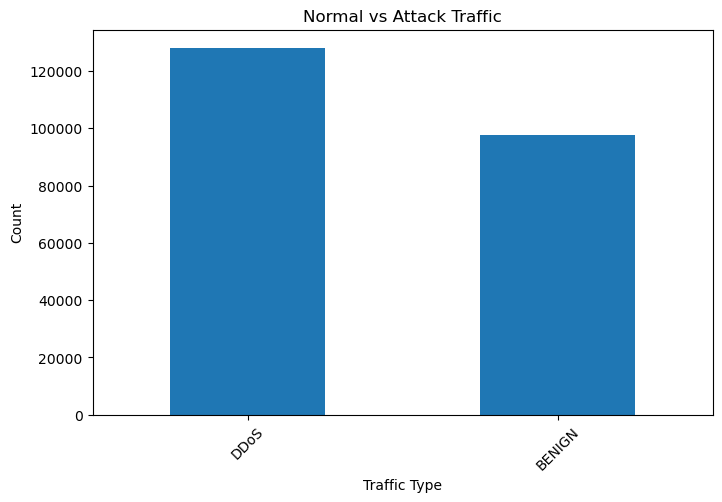

In [6]:

import matplotlib.pyplot as plt

df[' Label'].value_counts().plot(kind='bar', figsize=(8,5))

plt.title("Normal vs Attack Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## Data Preprocessing

In [7]:

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Convert column names
df.columns = df.columns.str.strip()

# Encode target label
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Label'])

# Convert non numeric columns
for column in df.columns:
    if df[column].dtype == 'object':
        encoder = LabelEncoder()
        df[column] = encoder.fit_transform(df[column].astype(str))

# Features and labels
X = df[['Flow Duration',
        'Total Fwd Packets',
        'Total Backward Packets',
        'Flow Bytes/s',
        'Flow Packets/s',
        'Packet Length Mean',
        'Average Packet Size']]
y = df['Label']

# Handle missing values
X = X.fillna(0)

import numpy as np

X = X.replace([np.inf, -np.inf], 0)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (180596, 7)
Testing Data: (45149, 7)


## Model Training

In [8]:

model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

print("Model Training Completed")


Model Training Completed


## Prediction and Accuracy

In [9]:

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", round(accuracy * 100, 2), "%")


Accuracy: 94.3 %


## Model Evaluation

In [10]:

print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)

print("\nConfusion Matrix:\n")
print(cm)


              precision    recall  f1-score   support

           0       1.00      0.87      0.93     19405
           1       0.91      1.00      0.95     25744

    accuracy                           0.94     45149
   macro avg       0.95      0.93      0.94     45149
weighted avg       0.95      0.94      0.94     45149


Confusion Matrix:

[[16882  2523]
 [   52 25692]]
